# Throughput Monitor Lab

Explore `measure_throughput` with a fixed message pane and a live dashboard.
Run cells individually: setup, optional dark/calibration/manual work, then the throughput section.
The saved outputs and exploratory plots are historical lab observations, not current hardware status.

Use the workspace `.venv` kernel in JupyterLab. The dashboard uses `ipympl`
(`%matplotlib widget`), `ipywidgets`, and Matplotlib's normal toolbar and animation.
After installing ipympl, reload the JupyterLab page if the widget frontend is missing.

**Stop measurement / laser off** below stops the selected channel and explicitly
sets `LASER` to zero. Pausing or closing a display does not stop acquisition.
Laser-bank power and TECs remain available for temperature monitoring.


In [1]:
from __future__ import annotations

from dataclasses import dataclass
import math
import time
from typing import Literal

import matplotlib.pyplot as plt
import numpy as np

try:
    from scipy.optimize import least_squares
except ImportError:
    least_squares = None

import hispec_fibpcb as hspcb

BROKER = "hispec.caltech.edu"
LASER = "1028y"
OUTPUT = "yj_ao"
FIBER = "M"
PD_CHANNEL = "yj"


TAKE_DARK_HK=TAKE_DARK_YJ=True
DARK_DURATION_MS = 2000


FIRMWARE_CORRECTION_TERMS = hspcb.ATTENUATOR_MODEL_CORRECTION_TERMS
TX_MIN = hspcb.ATTEN_CAL_MIN_TX
TX_MAX = hspcb.ATTEN_CAL_MAX_TX
MAX_DAC_MV = hspcb.ATTENUATOR_DRIVE_MAX_MV
ADC_CLIP_MV = hspcb.ATTENUATOR_ADC_CLIP_MV
GAIN = hspcb.ATTENUATOR_DEFAULT_GAIN
FIT_MIN_SIGMA_DB = hspcb.ATTENUATOR_FIT_MIN_SIGMA_DB

pcb = hspcb.HispecFibPcb(BROKER, connect=True)
pcb.status(), pcb.time()


(Status(
   fw='cd7fe2869789-dirty',
   boots=3,
   board='tib',
   board_ok=True,
   mems_switches=8,
   relay_err=0,
   amb_c=20.125,
   pd_on_s=0,
   laserbank_on_s=1257,
   lastcmd=LastCommand(name='measure_throughput', src='mqtt', t_ms=819526),
   ip=None,
   lasers=(),
   attens=()
 ),
 TimeStatus(utc=1789176522863, uptime_s=1258))

## Dark

Dark is deliberately outside attenuator calibration. Take or force the channel dark here, then leave calibration to read the photodiode configurable window.



In [6]:
pcb.set_laser_level('1028y', 0)
pcb.atten('1028y', value1_mv=3300, value2_mv=3300)
pcb.set_laser_level('1430hk', 0)
pcb.atten('1430hk', value1_mv=3300, value2_mv=3300)

AttenuatorState(
  db=110,
  linear=1.00008e-11,
  v1_mv=3299.19,
  v2_mv=3299.19,
  db1=54.9998,
  db2=54.9998,
  linear1=3.1624e-06,
  linear2=3.1624e-06
)

In [7]:
if TAKE_DARK_YJ:
    print('Initial', pcb.pd('yj'))
    pcb.pd_dark('yj', duration_ms=DARK_DURATION_MS, persist=True)
time.sleep(DARK_DURATION_MS/1000+.1)
print(pcb.pd('yj'))
if TAKE_DARK_HK:
    print('Initial', pcb.pd('hk'))
    pcb.pd_dark('hk', duration_ms=DARK_DURATION_MS, persist=True)
time.sleep(DARK_DURATION_MS/1000+.1)
print(pcb.pd('hk'))



Initial PhotodiodeValues(
  yj=PhotodiodeChannelValues(
  raw=-19,
  mv=-1.188,
  net_mv=-2049.12,
  net_err_mv=0.062,
  power_uw=0,
  power_err_uw=0,
  dark_mv=2047.94,
  dark_err_mv=0,
  window=PhotodiodeWindow(
  duration_ms=500,
  failed_samples=0,
  mean_mv=-1.728,
  mean_net_mv=-2049.66,
  rms_mv=0.399,
  mean_net_err_mv=0.08,
  min_mv=-2.375,
  max_mv=-1,
  power_uw=0,
  power_err_uw=0
),
  pd_is_off=False,
  ontime_s=139
),
  hk=None
)
PhotodiodeValues(
  yj=PhotodiodeChannelValues(
  raw=-26,
  mv=-1.625,
  net_mv=0.074,
  net_err_mv=0.444,
  power_uw=0,
  power_err_uw=0,
  dark_mv=-1.699,
  dark_err_mv=0.439,
  window=PhotodiodeWindow(
  duration_ms=500,
  failed_samples=0,
  mean_mv=-1.77,
  mean_net_mv=-1229.85,
  rms_mv=0.431,
  mean_net_err_mv=0.448,
  min_mv=-2.688,
  max_mv=-0.625,
  power_uw=0,
  power_err_uw=0
),
  pd_is_off=False,
  ontime_s=141
),
  hk=None
)
Initial PhotodiodeValues(
  yj=None,
  hk=PhotodiodeChannelValues(
  raw=42,
  mv=2.625,
  net_mv=-0.076,
  

## Embedded Atten Auto-calibration

Run the on-board algorithm, then fetch metadata plus fixed raw-record chunks. The Python helper derives bridge scale, scaled signal, transmission, dB attenuation, fit inclusion, residuals, and role markers from those records.



In [8]:
embedded_status = pcb.atten_calibrate_auto('1028y', output='yj_ao', fiber='M', dwell_ms=550, persist=True)
embedded_status


AttenuatorCalibrationStatus(
  state='running', mode='tib_auto', physical='dac1', point='1/128', complete_pct=0,
  mv=0, other_mv=3300, t_ms=550, error=0, fit='none',
  dac1=AttenuatorFitMetrics(valid=False),
  dac2=AttenuatorFitMetrics(valid=False)
)

PCB warning photodiode_noise: photodiode fixed-window RMS exceeded warning threshold context=channel=yj fixed_rms_mv=354.678 threshold_mv=10.000 uptime_s=0


In [16]:
pcb.atten_calibration_status()


AttenuatorCalibrationStatus(
  state='complete', mode='tib_auto', physical='dac2', point='92/128', complete_pct=100,
  mv=2950, other_mv=4.77128, t_ms=550, error=0, fit='ok',
  dac1=AttenuatorFitMetrics(accepted=True, points=30, fvoa_50pct_mv=3330.57, slope_inv_fvoa_mv=0.00301142, max_atten_db=64.0242, max_atten_sigma_db=2.41662, corr=0.99904, rms_db=1.01528, max_abs_db=4.69835, correction_coeff=(0, 0, 0, 0), fvoa_span_mv=4215.75),
  dac2=AttenuatorFitMetrics(accepted=True, points=54, fvoa_50pct_mv=3199.59, slope_inv_fvoa_mv=0.00298085, max_atten_db=55.5561, max_atten_sigma_db=3.48784, corr=0.997899, rms_db=1.07763, max_abs_db=6.67481, correction_coeff=(0, 0, 0, 0), fvoa_span_mv=4445.7)
)

In [17]:
pcb.set_laser_level('1028y', 0)
pcb.atten('1028y', value1_mv=3300, value2_mv=3300)
pcb.set_laser_level('1430hk', 0)
pcb.atten('1430hk', value1_mv=3300, value2_mv=3300)
embedded = pcb.atten_calibration_data(physical="all")


PCB warning photodiode_noise: photodiode fixed-window RMS exceeded warning threshold context=channel=yj fixed_rms_mv=22.588 threshold_mv=10.000 uptime_s=0


AttenuatorCalibrationDataset(
  records=187,
  physicals=('dac1', 'dac2'),
  counts=(('dac1', 95), ('dac2', 92))
)


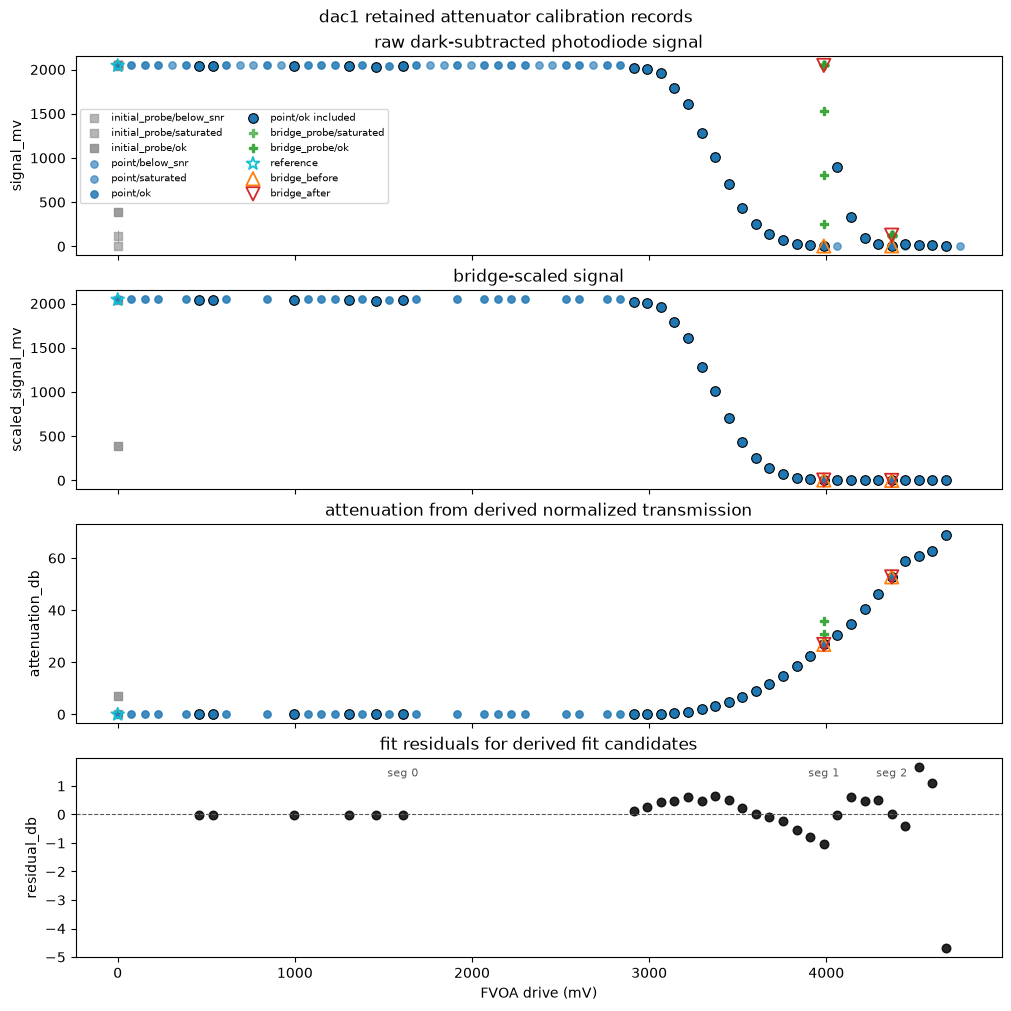

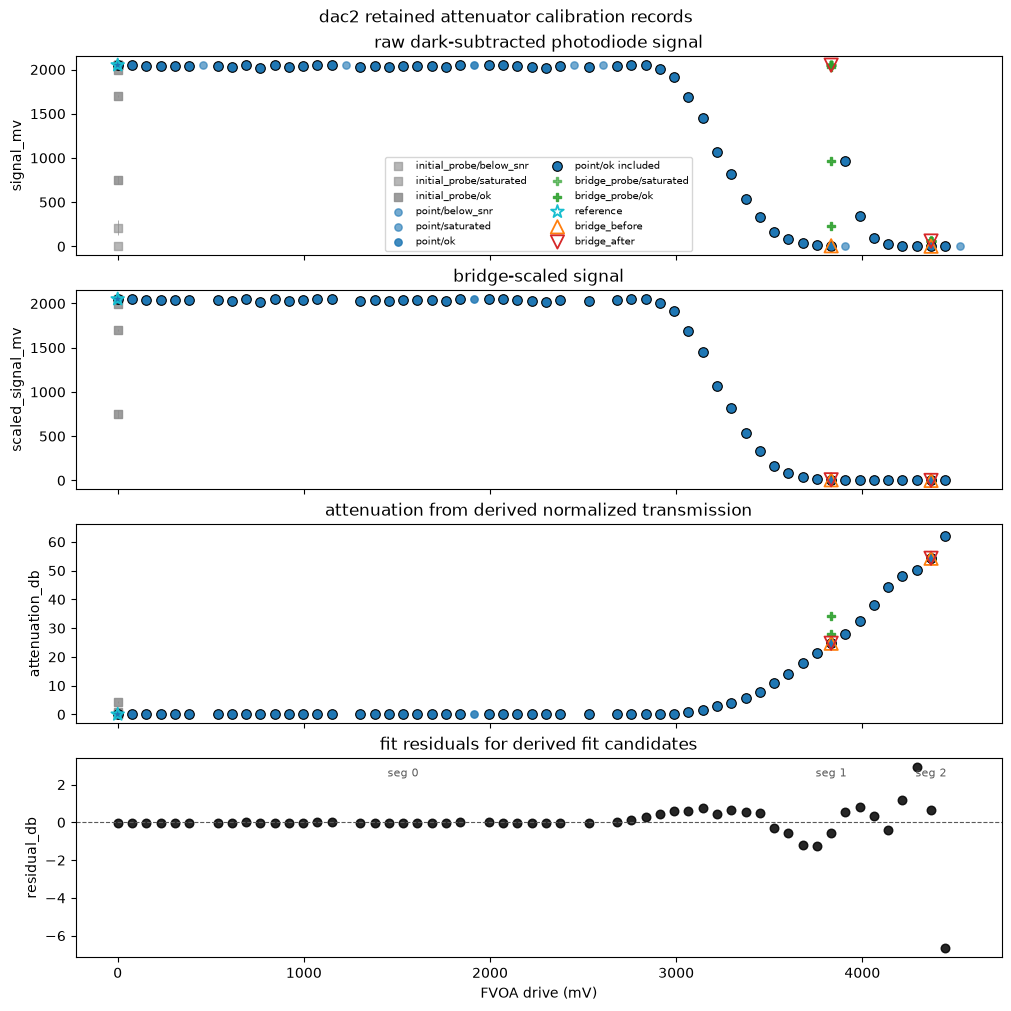

In [18]:
print(embedded)
embedded.bridge_table()
embedded.plot_physical("dac1");
embedded.plot_physical("dac2");



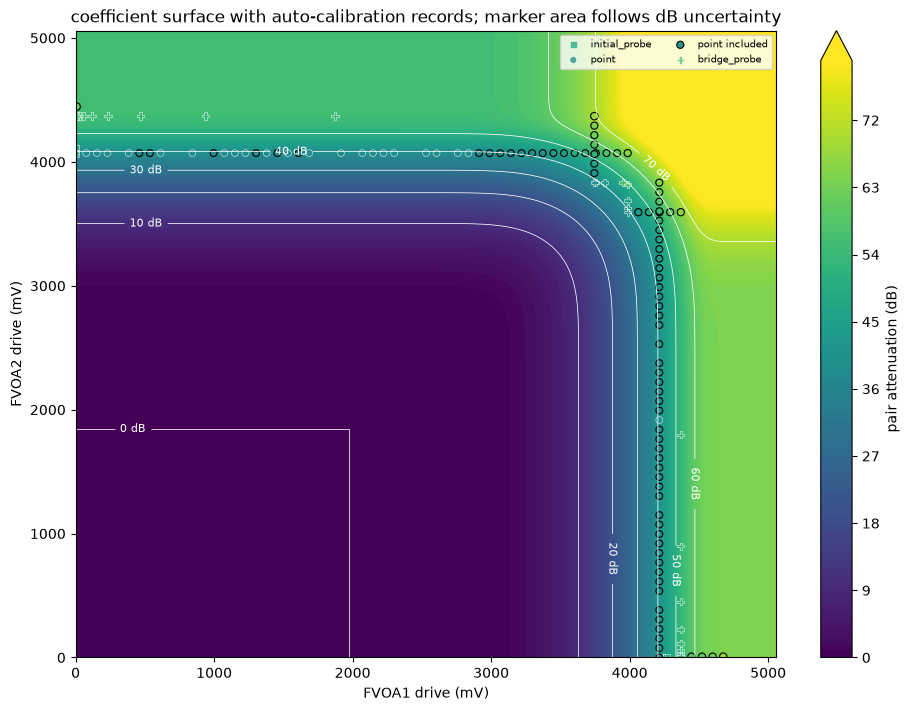

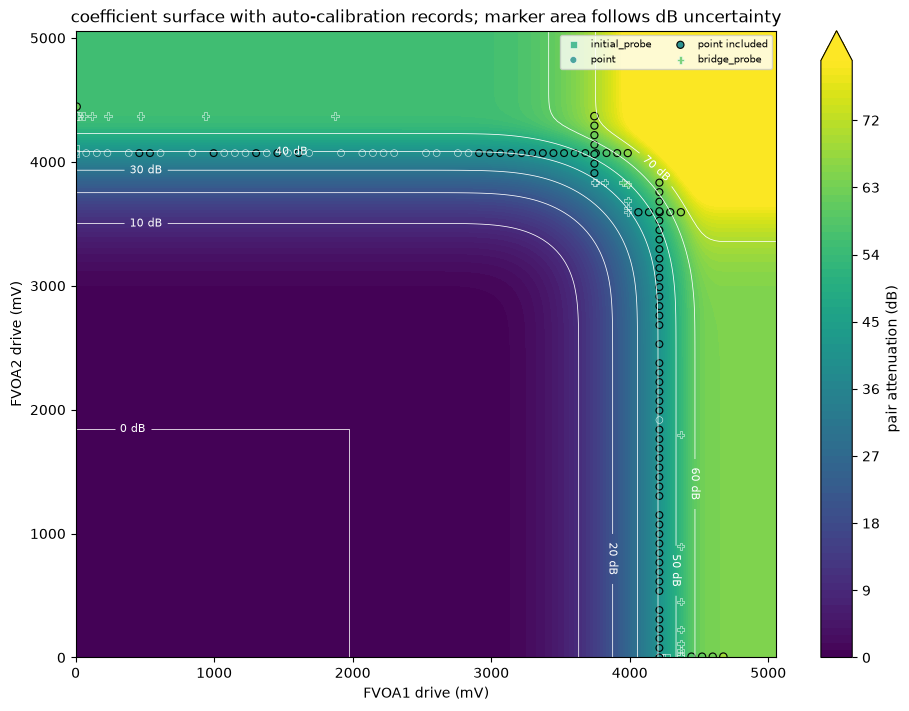

In [19]:
coeff = pcb.atten_coeff(LASER)
embedded.plot_surface(coeff.dac1, coeff.dac2, overlay_records=True)



In [26]:
## Manually verify levels

In [45]:
pcb.pd('yj')
pcb.atten('1028y', value_db=99)
pcb.set_laser_level('1028y', 0)
time.sleep(1)
print('OFF', pcb.pd('yj'))
pcb.atten('1028y', value_db=99)
pcb.set_laser_level('1028y', 100)
time.sleep(1)
print('Laser 100, atten 99', pcb.pd('yj'))
pcb.atten('1028y', value_db=0)
pcb.set_laser_level('1028y', 2)
time.sleep(.5)
print('Laser 2, atten 0', pcb.pd('yj'))
pcb.atten('1028y', value_db=40)
pcb.set_laser_level('1028y', 2)
time.sleep(1)
print('Laser 2, atten 20db', pcb.pd('yj'))
pcb.set_laser_level('1028y', 0)

PCB warning photodiode_noise: photodiode fixed-window RMS exceeded warning threshold context=channel=yj fixed_rms_mv=194.979 threshold_mv=10.000 uptime_s=0
PCB warning photodiode_noise: photodiode fixed-window RMS exceeded warning threshold context=channel=yj fixed_rms_mv=194.979 threshold_mv=10.000 uptime_s=0


OFF PhotodiodeValues(
  yj=PhotodiodeChannelValues(
  raw=-30,
  mv=-1.875,
  net_mv=-145.287,
  net_err_mv=7.59,
  power_uw=0,
  power_err_uw=0,
  dark_mv=143.412,
  dark_err_mv=7.59,
  window=PhotodiodeWindow(
  duration_ms=500,
  failed_samples=0,
  mean_mv=-1.54,
  mean_net_mv=-144.952,
  rms_mv=0.353,
  mean_net_err_mv=7.59,
  min_mv=-2.312,
  max_mv=-0.875,
  power_uw=0,
  power_err_uw=0
),
  pd_is_off=False,
  ontime_s=441
),
  hk=None
)
Laser 100, atten 99 PhotodiodeValues(
  yj=PhotodiodeChannelValues(
  raw=-31,
  mv=-1.938,
  net_mv=-145.35,
  net_err_mv=7.59,
  power_uw=0,
  power_err_uw=0,
  dark_mv=143.412,
  dark_err_mv=7.59,
  window=PhotodiodeWindow(
  duration_ms=500,
  failed_samples=0,
  mean_mv=-1.712,
  mean_net_mv=-145.125,
  rms_mv=0.26,
  mean_net_err_mv=7.59,
  min_mv=-2.25,
  max_mv=-1.188,
  power_uw=0,
  power_err_uw=0
),
  pd_is_off=False,
  ontime_s=443
),
  hk=None
)
Laser 2, atten 0 PhotodiodeValues(
  yj=PhotodiodeChannelValues(
  raw=32767,
  mv=2047.

CommandOk(status='ok')

In [46]:
pcb.pd('yj')
pcb.atten('1028y', value_db=99)
pcb.set_laser_level('1028y', 0)
time.sleep(1)
pcb.pd('yj')

PhotodiodeValues(
  yj=PhotodiodeChannelValues(
  raw=-26,
  mv=-1.625,
  net_mv=-145.037,
  net_err_mv=7.59,
  power_uw=0,
  power_err_uw=0,
  dark_mv=143.412,
  dark_err_mv=7.59,
  window=PhotodiodeWindow(
  duration_ms=500,
  failed_samples=0,
  mean_mv=-1.655,
  mean_net_mv=-145.067,
  rms_mv=0.419,
  mean_net_err_mv=7.59,
  min_mv=-2.812,
  max_mv=-0.75,
  power_uw=0,
  power_err_uw=0
),
  pd_is_off=False,
  ontime_s=451
),
  hk=None
)

## Explore throughput monitoring

Run the message pane before starting acquisition. It displays all messages received
by this `pcb` connection, including replies, warnings, and binary throughput packets
as escaped bytes. The latest 500 log records stay here even while later cells run.

The measurement uses binary telemetry to preserve small uncertainties. The command
and Python helper still support `format="json"`. Channel plus wavelength identifies
the source, including the two 1430 nm lasers.

The dashboard refreshes every 0.5 s and shows the latest 600 records. Collection
retains up to 20,000 records independently. Reported errors do not account for all
20 Hz filter correlations; use these plots to investigate settling and oscillation.

Both photodiodes can stream. Dual autolevel is available for engineering with
optically isolated paths; normal instrument light paths overlap and should use
only one loop. Additional manually enabled lasers also affect these readings.


In [20]:
import logging
import ipywidgets as widgets
from IPython.display import display

# Rerunning replaces only this pane and restores the prior client logger first.
if "message_handler" in globals():
    message_client.logger = previous_logger
    message_logger.removeHandler(message_handler)
    message_handler.close()
    message_output.close()

class MessagePaneHandler(logging.Handler):
    """Write explicitly to one widget, including from the MQTT thread."""
    def __init__(self, output):
        super().__init__()
        self.output = output

    def emit(self, record):
        try:
            entry = {"output_type": "stream", "name": "stdout",
                     "text": self.format(record) + "\n"}
            self.output.outputs = (*self.output.outputs[-499:], entry)
        except Exception:
            self.handleError(record)

# message_client = pcb
# previous_logger = pcb.logger
# message_logger = logging.Logger(f"throughput.lab.{pcb.device}", level=logging.DEBUG)
# message_logger.propagate = False
# message_output = widgets.Output(layout={"height": "260px", "overflow": "auto",
#                                         "border": "1px solid #999"})
# message_handler = MessagePaneHandler(message_output)
# message_handler.setFormatter(logging.Formatter("%(asctime)s %(levelname)s %(message)s"))
# message_logger.addHandler(message_handler)
# pcb.logger = message_logger
# display(message_output)


In [21]:
# Start/replace the selected channel. Use one autolevel loop on overlapping light paths.
# Preserve the prior collector if firmware rejects this start.
previous_monitor = globals().get("monitor")
monitor = pcb.measure_throughput(
    LASER,
    fiber=FIBER,
    output=OUTPUT,
    autolevel=True,
    collect=True,
    format="binary",
    off_in_s=300,
)
if previous_monitor is not None and previous_monitor.channel == monitor.channel:
    previous_monitor._stop_collection()  # Local cleanup after successful replacement.


PCB warning attenuator_clamped: attenuator command exceeded modeled range and was clamped context=requested=120.000 clamped=119.580 uptime_s=0


### Live dashboard (display controls only)

Pan/zoom with the toolbar; **Follow data** restores autoscaling. Pause freezes
only the display. Closing the figure stops its timer. Neither action changes
collection or laser output. Rerun this cell to replace the display.

The panels show throughput ± error; raw ADC input and net mean ± error; laser
current and combined attenuation on separate axes; and estimated photodiode/emitted
photon flux ± error on a log scale. Nonpositive flux and invalid values are gaps.


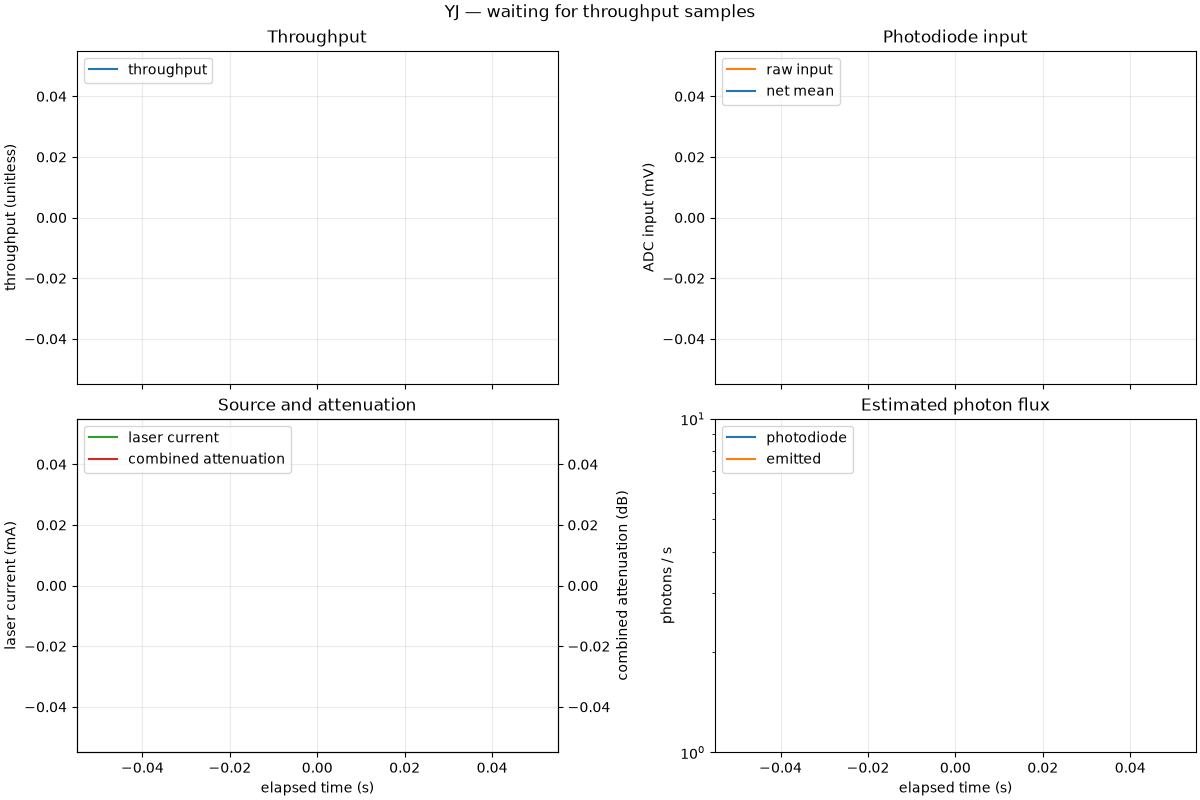

In [22]:
%matplotlib widget

# Keep the animation referenced and remove the old figure/timer on rerun.
if "tp_animation" in globals():
    plt.close(tp_figure)
    for control in tp_controls.children:
        control.close()
    tp_controls.close()
with plt.ioff():
    tp_figure, tp_animation = monitor.plot_live(channel=PD_CHANNEL, max_points=600)

pause_display = widgets.ToggleButton(description="Pause display", value=False)
follow_data = widgets.Button(description="Follow data")

def toggle_display(change):
    if tp_animation.event_source is None or tp_figure.canvas.comm is None:
        return  # The figure has already been closed.
    if change["new"]:
        tp_animation.pause()
    else:
        tp_animation.resume()
    pause_display.description = "Resume display" if change["new"] else "Pause display"

def follow_display(_button):
    for ax in tp_figure.axes:
        ax.set_autoscale_on(True)

pause_display.observe(toggle_display, names="value")
follow_data.on_click(follow_display)
tp_controls = widgets.HBox([pause_display, follow_data])
display(tp_controls, tp_figure.canvas)


In [26]:
# # Optional snapshot save (does not stop collection). 
from pathlib import Path
import csv

snapshot = monitor.to_recarray()
snapshot_path = Path(f"throughput_{LASER}_{time.strftime('%Y%m%d_%H%M%S')}.csv")
with snapshot_path.open("w", newline="") as output_file:
    writer = csv.writer(output_file)
    writer.writerow(snapshot.dtype.names)
    writer.writerows(snapshot.tolist())
snapshot_path


PosixPath('throughput_1028y_20260911_183707.csv')

In [23]:
# Stop measurement / laser off. Always attempt the explicit zero-level command.
# Errors remain visible, including chained errors if both commands fail.
try:
    monitor.stop()
finally:
    pcb.set_laser_level(LASER, 0)


In [24]:
# Confirm the selected laser's current state after shutdown.
pcb.laser(LASER)


LaserStatus(
  name='1028y',
  powered=True,
  tec_on_s=1598,
  emit_on_s=None,
  emit_total_s=None,
  temp_c=24.75,
  i_mA=0,
  level=0,
  power_mw=0,
  nominal_nm=1028.01,
  tuned_nm=1028.01,
  tune_nm=0,
  tec_ma=0,
  diode_v=0.2,
  tec_v=0.1,
  off_in_s=None,
  oc_fault=False
)

In [25]:
# Optional display/log cleanup. Run the laser-off cell above first.
if "tp_animation" in globals():
    plt.close(tp_figure)
    for control in tp_controls.children:
        control.close()
    tp_controls.close()
if "message_handler" in globals():
    message_client.logger = previous_logger
    message_logger.removeHandler(message_handler)
    message_handler.close()
    message_output.close()
    del message_handler
